# Creation and visualization of quadrilateral shapes

This notebook walks through the quadrilateral primitives in
`metashapes.shape.primitives.quads`: **`Rectangle`**, **`ConvexQuad`**, and
**`IsoscelesTrapezoid`**. For each one we:

1. construct it and place it in a `UnitCell`,
2. look at its parametric (serializable) representation,
3. sample the cell's periodic SDF,
4. rasterize it into a binary mask,
5. look at the Shapely geometry `UnitCell.to_shapely()` gives us, and
6. compare that geometry's raster against the SDF mask to see they agree
   almost everywhere.

In [86]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle, ConvexQuad, IsoscelesTrapezoid
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell
from metashapes.adapters.shapely.raster import shapely_to_numpy

dtype = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Shapes live in a `UnitCell`

A `Shape` on its own lives in infinite, continuous space -- it knows nothing
about periodicity. A `UnitCell` pairs a `Shape` (the "scene") with a
`Lattice`, and turns the shape's SDF into a *periodic* SDF by taking the
minimum over neighboring lattice copies. Below, one `Rectangle` is tiled
3x3 to make that periodicity visible before we look at single cells in
detail.

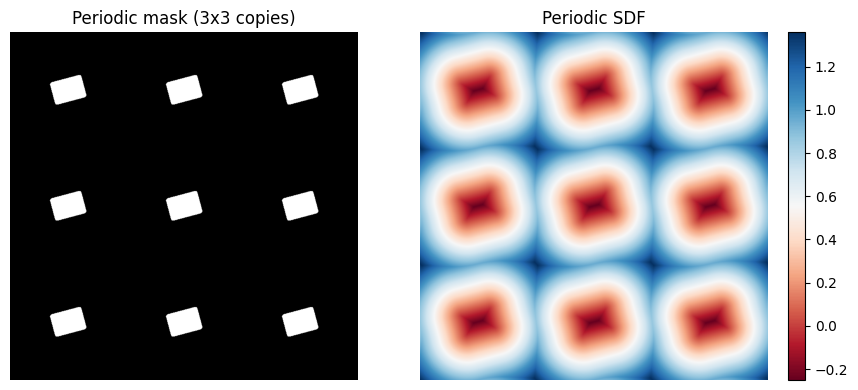

In [87]:
lattice = Lattice.rectangular(2.5, 2.5).to(dtype=dtype, device=device)

demo = Rectangle(center=[0.0, 0.0], size=[0.7, 0.5], angle=15.0, corner_radius=0.05)
demo = demo.to(dtype=dtype, device=device)
demo_cell = UnitCell(lattice=lattice, scene=demo).center_scene(method='bbox')

nx = ny = 256
mask = demo_cell.mask(nx, ny, cartesian=True, repeat=(3, 3))
sdf_periodic = demo_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mask.cpu().detach(), origin='lower', cmap='gray')
axes[0].set_title('Periodic mask (3x3 copies)')
im = axes[1].imshow(sdf_periodic.cpu().detach(), origin='lower', cmap='RdBu')
axes[1].set_title('Periodic SDF')
plt.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.axis('off')
fig.tight_layout()
plt.show()

## Two views of a shape: parametric and Shapely

Before getting to SDF/mask comparisons, it's worth looking at a shape two
other ways:

- **`shape.to_parametric()`** -- the plain dict of constructor arguments
  `Shape` serialization uses (see `metashapes.adapters.yaml`). This is the
  most direct way to see exactly what values a shape actually holds.
- **`UnitCell.to_shapely()`** -- the cell's scene as a Shapely geometry,
  wrapped periodically into the cell. Displayed directly (not rasterized),
  Jupyter renders it as a vector image via Shapely's own SVG repr, which is
  a nice complement to the raster masks below.

`show_parametric()` is a tiny helper that just rounds the (float32-noisy)
values for readability before printing.

In [88]:
def show_parametric(shape, ndigits=4):
    """Pretty-print shape.to_parametric(), rounded for readability."""
    def _round(v):
        if isinstance(v, float):
            return round(v, ndigits)
        if isinstance(v, list):
            return [_round(x) for x in v]
        if isinstance(v, dict):
            return {k: _round(x) for k, x in v.items()}
        return v
    data = _round(shape.to_parametric())
    return data

## Inspecting a single cell: SDF, mask, and Shapely agreement

`show_cell()` below is a small helper used identically for all three
primitives. Given a `UnitCell`, it:

- samples the cell's periodic SDF and hard mask via `rasterize()`/`mask()`,
- converts the *same* cell to Shapely via `UnitCell.to_shapely()` (which
  wraps the scene periodically into the cell, matching what `mask()`
  represents -- not `shape_to_shapely()` on the bare shape, which knows
  nothing about the lattice),
- rasterizes that Shapely polygon onto the exact grid `rasterize()` used
  internally, via `shapely_to_numpy()`, and
- reports where the two masks disagree.

The two masks won't agree at literally every pixel -- the SDF and Shapely
rasterize a curved or rounded boundary very slightly differently -- but the
agreement should be well above 99%; a much lower number would mean
something is actually wrong.

In [89]:
def show_cell(cell, title=None, nx=256, ny=256):
    """Plot a UnitCell's SDF, the hard mask derived from it, the mask from
    UnitCell.to_shapely(), and where the two masks disagree. Single cell
    (repeat=(1, 1)), since to_shapely() itself represents exactly one cell.
    """
    xmin, xmax, ymin, ymax = cell.extent()

    sdf = cell.rasterize(nx, ny, cartesian=True).detach().cpu().numpy()
    mask_sdf = cell.mask(nx, ny, cartesian=True).detach().cpu().numpy().astype(bool)

    # Same grid rasterize(cartesian=True) builds internally, so the Shapely
    # mask below is compared pixel-for-pixel against the same sample points.
    fx = torch.arange(nx, dtype=dtype, device=device) / nx
    fy = torch.arange(ny, dtype=dtype, device=device) / ny
    xs = xmin + fx * (xmax - xmin)
    ys = ymin + fy * (ymax - ymin)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    Xn, Yn = X.detach().cpu().numpy(), Y.detach().cpu().numpy()

    geom = cell.to_shapely()
    mask_shapely = shapely_to_numpy(geom, Xn, Yn)

    mismatch = mask_sdf != mask_shapely
    agreement = 100.0 * (1.0 - mismatch.mean())

    extent = [xmin, xmax, ymin, ymax]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    im0 = axes[0].imshow(sdf, origin="lower", extent=extent, cmap="RdBu")
    axes[0].contour(Xn, Yn, sdf, levels=[0.0], colors="k", linewidths=1.2)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    axes[0].set_title("SDF")

    axes[1].imshow(mask_sdf, origin="lower", extent=extent, cmap="gray")
    axes[1].set_title("Mask from SDF\n(UnitCell.mask())")

    axes[2].imshow(mask_shapely, origin="lower", extent=extent, cmap="gray")
    axes[2].set_title("Mask from Shapely\n(UnitCell.to_shapely())")

    axes[3].imshow(mismatch, origin="lower", extent=extent, cmap="Reds")
    axes[3].set_title(f"Mismatch\n({agreement:.3f}% agree)")

    for ax in axes:
        ax.set_aspect("equal")
        ax.axis("off")

    fig.suptitle(title or type(cell.scene).__name__, fontsize=14, y=1.03)
    fig.tight_layout()
    plt.show()

    label = title or type(cell.scene).__name__
    print(f"{label}: mask/Shapely agreement = {agreement:.3f}% "
          f"({mismatch.sum()} / {mismatch.size} pixels differ)")

## `Rectangle`

Parameters: `center`, `size` (width, height), `angle` (degrees), and
`corner_radius` (0 = sharp corners). The example below combines rotation
*and* rounded corners so both features are visible at once.

In [90]:
rect = Rectangle(
    center=[0.0, 0.0],
    size=[1.2, 0.7],
    angle=25.0,
    corner_radius=0.15,
)
rect = rect.to(dtype=dtype, device=device)
rect_cell = UnitCell(lattice=lattice, scene=rect).center_scene(method='bbox')

In [91]:
show_parametric(rect)

{'type': 'Rectangle',
 'center': [0.0, 0.0],
 'size': [1.2, 0.7],
 'angle': 25.0,
 'corner_radius': 0.15}

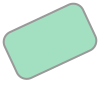

In [92]:
rect_cell.to_shapely()

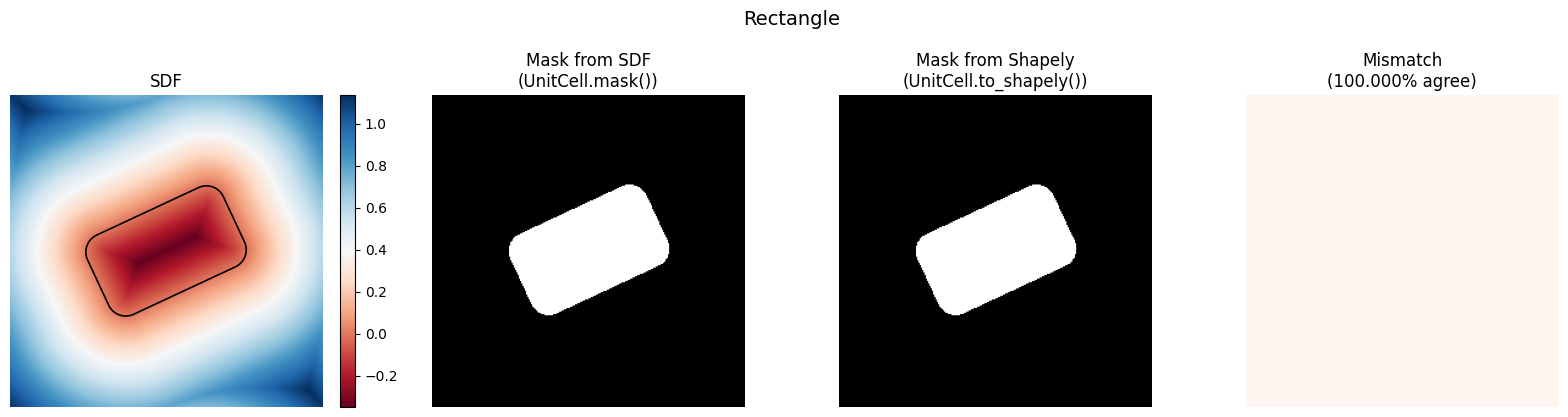

Rectangle: mask/Shapely agreement = 100.000% (0 / 65536 pixels differ)


In [93]:
show_cell(rect_cell, title="Rectangle")

## `ConvexQuad`

A more general shape than `Rectangle`: it's built from a center and two
frame vectors `u`, `v` (placing corners at combinations of ±u and ±v), with
`alpha`/`beta` stretching the far corner along each direction. With
`alpha = beta = 0` and orthogonal `u`/`v` it reduces to a rectangle; the
example below uses a non-orthogonal `u`/`v` (a sheared parallelogram) and
nonzero `alpha`/`beta`, so the result is visibly a general quadrilateral,
not a disguised rectangle.

In [94]:
quad = ConvexQuad(
    center=[0.0, 0.0],
    u=[0.7, 0.15],
    v=[0.1, 0.5],
    alpha=0.4,
    beta=-0.2,
    corner_radius=0.06,
)
quad = quad.to(dtype=dtype, device=device)
quad_cell = UnitCell(lattice=lattice, scene=quad).center_scene(method='bbox')

In [95]:
show_parametric(quad)

{'type': 'ConvexQuad',
 'center': [0.0, 0.0],
 'u': [0.7, 0.15],
 'v': [0.1, 0.5],
 'alpha': 0.4,
 'beta': -0.2,
 'angle': 0.0,
 'corner_radius': 0.06}

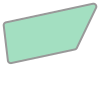

In [96]:
quad_cell.to_shapely()

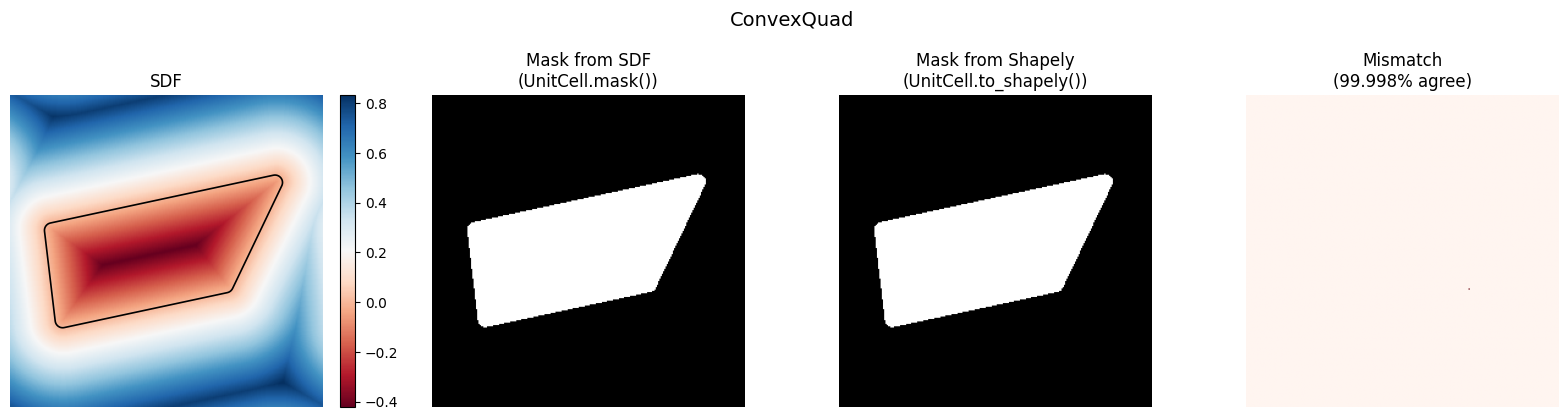

ConvexQuad: mask/Shapely agreement = 99.998% (1 / 65536 pixels differ)


In [97]:
show_cell(quad_cell, title="ConvexQuad")

## `IsoscelesTrapezoid`

Parameters: `bottom_width`, `top_width`, `height`, `angle`, and
`corner_radius`. The example below uses a top base narrower than the
bottom (`top_width < bottom_width`), a moderate `corner_radius`, and a
slight rotation.

In [98]:
trap = IsoscelesTrapezoid(
    center=[0.0, 0.0],
    bottom_width=1.0,
    top_width=0.5,
    height=0.8,
    angle=10.0,
    corner_radius=0.08,
)
trap = trap.to(dtype=dtype, device=device)
trap_cell = UnitCell(lattice=lattice, scene=trap).center_scene(method='bbox')

In [99]:
show_parametric(trap)

{'type': 'IsoscelesTrapezoid',
 'center': [0.0, 0.0],
 'bottom_width': 1.0,
 'top_width': 0.5,
 'height': 0.8,
 'angle': 10.0,
 'corner_radius': 0.08}

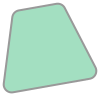

In [100]:
trap_cell.to_shapely()

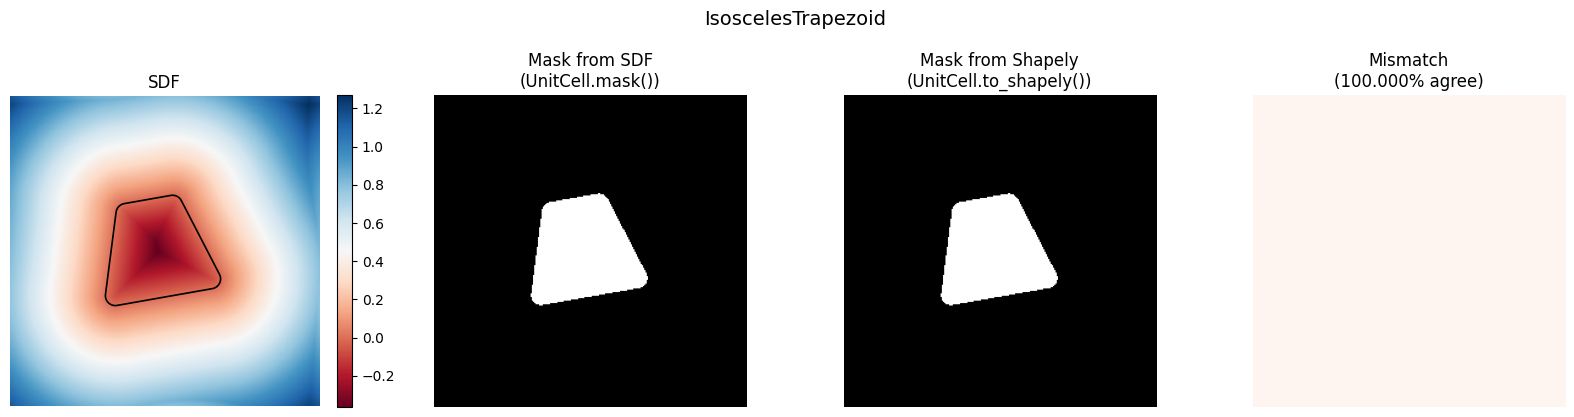

IsoscelesTrapezoid: mask/Shapely agreement = 100.000% (0 / 65536 pixels differ)


In [101]:
show_cell(trap_cell, title="IsoscelesTrapezoid")